In [2]:
# ============================================================
# =============== CELL A — USER INPUTS ONLY ==================
# ============================================================

# ---- Parent session folder (contains multiple camera subfolders) ----
SESSION_FOLDER = r"D:\Kevin\05032026" #######################################################################################################################################################################

# ---- NI-DAQ TTL folder (Neuropixels session) ----
NI_TTL_FOLDER = r"G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL" ####################################################################################

# ---- Regex pattern for camera filenames ----
# Example: frame_030293_cnt_1575696.raw
FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw" ################################################################################################################################################

# ---- TTL pin for camera ----
TTL_PIN = 1  #########################################################################################################################################################################################

# ---- TTL block detection parameters ----
EXPECTED_RATE_HZ = 60  ####################################################################################################################################################################################
MISSING_TTL_THRESHOLD = 60  ###############################################################################################################################################################################
MIN_BLOCK_LENGTH = 1000   #################################################################################################################################################################################

print("User inputs loaded successfully.")
print(f"SESSION_FOLDER: {SESSION_FOLDER}")
print(f"NI_TTL_FOLDER: {NI_TTL_FOLDER}")
print(f"TTL_PIN: {TTL_PIN}")

User inputs loaded successfully.
SESSION_FOLDER: D:\Kevin\05032026
NI_TTL_FOLDER: G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL
TTL_PIN: 1



===== TTL BLOCK DETECTOR =====
Loaded NI-DAQ data: 665277 samples
Detected 164221 rising edges on pin 1

Detected 6 TTL blocks (before filtering)
Skipping block 0 (too short: 1 TTLs)
Skipping block 1 (too short: 1 TTLs)

Block 2:
  TTLs: 11632
  Start time: 676.130s
  End time:   870.096s
  Duration:   193.966s

Block 3:
  TTLs: 66686
  Start time: 931.433s
  End time:   2043.521s
  Duration:   1112.088s

Block 4:
  TTLs: 18733
  Start time: 2231.234s
  End time:   2543.624s
  Duration:   312.389s

Block 5:
  TTLs: 67168
  Start time: 2606.300s
  End time:   3726.428s
  Duration:   1120.127s


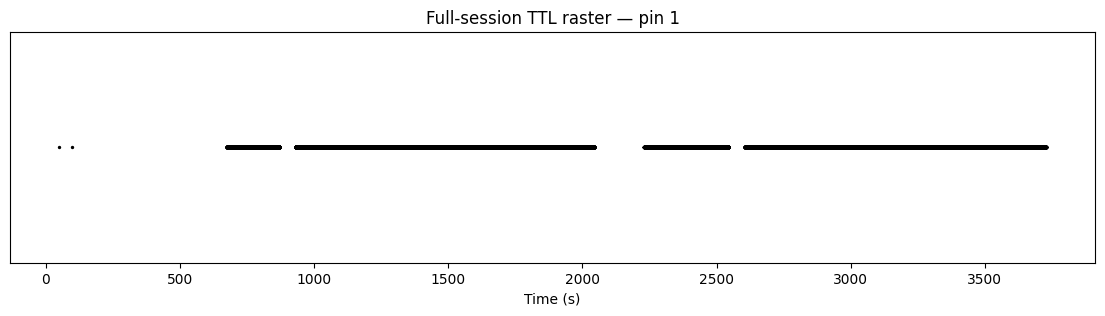

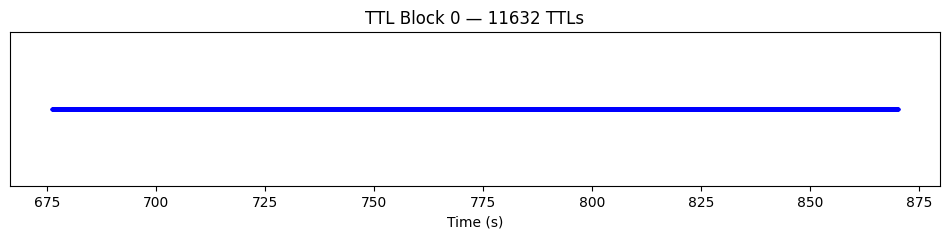

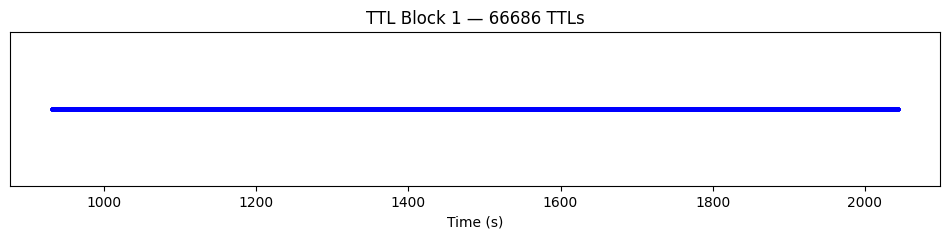

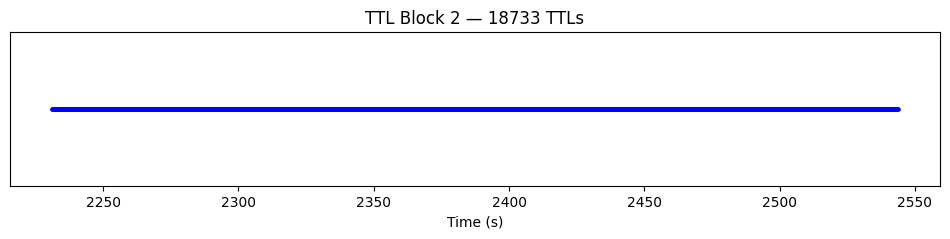

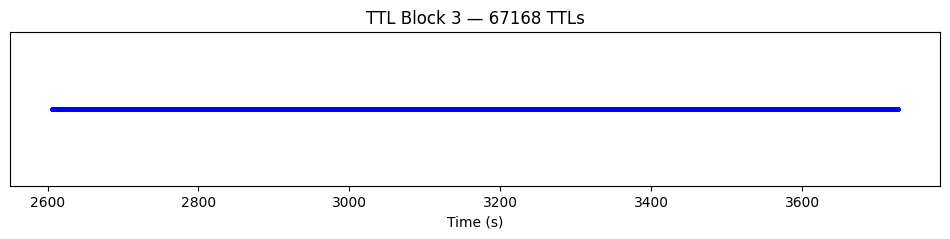


Review block_info and ttl_blocks above. If correct, proceed to Cell B.


In [3]:
# ============================================================
# CELL A-BLOCK — TTL BLOCK DETECTOR (NO SAVING)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("\n===== TTL BLOCK DETECTOR =====")

# ------------------------------------------------------------
# 1. Load NI-DAQ TTL data
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

print(f"Loaded NI-DAQ data: {len(full_words_ni)} samples")

# ------------------------------------------------------------
# 2. Extract rising edges for camera TTL pin
# ------------------------------------------------------------
mask = 1 << TTL_PIN
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx = (~bit_on_prev) & (bit_on)
rising_times = timestamps_ni[rising_idx]

print(f"Detected {len(rising_times)} rising edges on pin {TTL_PIN}")

# ------------------------------------------------------------
# 3. Detect TTL blocks
# ------------------------------------------------------------
ipi = np.diff(rising_times)
expected_ipi = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD

gap_mask = ipi > gap_threshold
gap_indices = np.where(gap_mask)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

print(f"\nDetected {len(block_starts)} TTL blocks (before filtering)")

# ------------------------------------------------------------
# 4. Build block list
# ------------------------------------------------------------
ttl_blocks = []
block_info = []

for b, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1

    if block_len < MIN_BLOCK_LENGTH:
        print(f"Skipping block {b} (too short: {block_len} TTLs)")
        continue

    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)

    info = {
        "block_index": b,
        "ttl_start_index": int(start),
        "ttl_end_index": int(end),
        "n_ttls": int(block_len),
        "start_time_sec": float(block_times[0]),
        "end_time_sec": float(block_times[-1]),
        "duration_sec": float(block_times[-1] - block_times[0]),
        "gap_threshold_sec": float(gap_threshold)
    }

    block_info.append(info)

    print(f"\nBlock {b}:")
    print(f"  TTLs: {block_len}")
    print(f"  Start time: {block_times[0]:.3f}s")
    print(f"  End time:   {block_times[-1]:.3f}s")
    print(f"  Duration:   {block_times[-1] - block_times[0]:.3f}s")

# ------------------------------------------------------------
# 5. Visualize full session
# ------------------------------------------------------------
plt.figure(figsize=(14, 3))
plt.scatter(rising_times, np.zeros_like(rising_times), s=2, c='k')
plt.title(f"Full-session TTL raster — pin {TTL_PIN}")
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()

# ------------------------------------------------------------
# 6. Visualize each block
# ------------------------------------------------------------
for b, block_times in enumerate(ttl_blocks):
    plt.figure(figsize=(12, 2))
    plt.scatter(block_times, np.zeros_like(block_times), s=3, c='blue')
    plt.title(f"TTL Block {b} — {len(block_times)} TTLs")
    plt.xlabel("Time (s)")
    plt.yticks([])
    plt.show()

print("\nReview block_info and ttl_blocks above. If correct, proceed to Cell B.")

In [4]:
# ============================================================
# =============== CELL A-MAP — CAMERA MAPPING ================
# ============================================================

import os

print("\n===== CAMERA FOLDER MAPPING =====")
print(f"Detected {len(ttl_blocks)} TTL blocks.")
print("Now define CAM_FOLDERS mapping manually based on your session structure.\n")

# ---- MANUAL MAPPING: block index → camera folder ----
CAM_FOLDERS = {
    0: r"D:\Kevin\05032026\05032026-6\cam2",      #######################################################################################################################################
    1: r"D:\Kevin\05032026\05032026-7\cam2",      #######################################################################################################################################
    2: r"D:\Kevin\05032026\05032026-8\cam2",      #######################################################################################################################################
    3: r"D:\Kevin\05032026\05032026-9\cam2",      #######################################################################################################################################
}

# ============================================================
# VALIDATION
# ============================================================

# 1. Check that mapping has exactly the right number of blocks
if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(
        f"❌ CAM_FOLDERS has {len(CAM_FOLDERS)} entries but ttl_blocks has {len(ttl_blocks)} blocks."
    )

# 2. Check that all block indices exist
expected_indices = set(range(len(ttl_blocks)))
mapped_indices = set(CAM_FOLDERS.keys())

if mapped_indices != expected_indices:
    raise ValueError(
        f"❌ CAM_FOLDERS keys {mapped_indices} do not match expected block indices {expected_indices}."
    )

# 3. Check that each camera folder exists
for b, path in CAM_FOLDERS.items():
    if not os.path.isdir(path):
        raise FileNotFoundError(
            f"❌ Camera folder for block {b} does not exist on disk:\n{path}"
        )

print("✅ Camera folders mapped to blocks successfully:")
for b, path in CAM_FOLDERS.items():
    print(f"  Block {b} → {path}")


===== CAMERA FOLDER MAPPING =====
Detected 4 TTL blocks.
Now define CAM_FOLDERS mapping manually based on your session structure.

✅ Camera folders mapped to blocks successfully:
  Block 0 → D:\Kevin\05032026\05032026-6\cam2
  Block 1 → D:\Kevin\05032026\05032026-7\cam2
  Block 2 → D:\Kevin\05032026\05032026-8\cam2
  Block 3 → D:\Kevin\05032026\05032026-9\cam2


In [6]:
# ============================================================
# =============== CELL D-MAP — DLC OUTPUT MAPPING ============
# ============================================================

print("\n===== DLC OUTPUT MAPPING =====")
print(f"Detected {len(ttl_blocks)} TTL blocks.")
print("Now define DLC_OUTPUTS mapping manually.\n")

# ---- MANUAL MAPPING: block index → DLC output file ----
DLC_OUTPUTS = {
    0: r"F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-6_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5",
    1: r"F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-7_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5",
    2: r"F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-8_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5",
    3: r"F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-9_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5",
}

# ---- VALIDATION ----
if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError("❌ DLC_OUTPUTS count does not match number of TTL blocks.")

expected = set(range(len(ttl_blocks)))
if set(DLC_OUTPUTS.keys()) != expected:
    raise ValueError("❌ DLC_OUTPUTS keys do not match block indices.")

for b, path in DLC_OUTPUTS.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(f"❌ DLC file for block {b} not found:\n{path}")

print("✅ DLC outputs mapped successfully:")
for b, path in DLC_OUTPUTS.items():
    print(f"  Block {b} → {path}")


===== DLC OUTPUT MAPPING =====
Detected 4 TTL blocks.
Now define DLC_OUTPUTS mapping manually.

✅ DLC outputs mapped successfully:
  Block 0 → F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-6_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5
  Block 1 → F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-7_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5
  Block 2 → F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-8_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5
  Block 3 → F:\03052026\mouse 1-030526-Kevin-2026-04-28\videos\05032026-9_cam2DLC_Resnet50_mouse 1-030526Apr28shuffle4_snapshot_best-30.h5


In [7]:
session = {"blocks": []}

for block_index, ttl_times_block in enumerate(ttl_blocks):
    block = {
        "block_index": block_index,
        "ttl_times": ttl_times_block,
        "cam_folder": CAM_FOLDERS[block_index],
        "aligned_frames": None,
        "dlc_aligned": None,
        "dlc_path": DLC_OUTPUTS[b],
        "dlc_aligned": None,
    }
    session["blocks"].append(block)

In [10]:
# ============================================================
# ========== CELL B — FRAME ALIGNMENT FOR ALL BLOCKS ==========
# ============================================================

import os
import re
import numpy as np

print("\n===== FRAME ALIGNMENT FOR ALL BLOCKS =====")

PATTERN = re.compile(FILENAME_PATTERN)

for block_index, block in enumerate(session["blocks"]):

    print(f"\n==============================")
    print(f"Processing block {block_index}")
    print("==============================")

    ttl_times_block = block["ttl_times"]
    CAM_FOLDER = block["cam_folder"]
    TTL_COUNT = len(ttl_times_block)

    print(f"TTL pulses in block: {TTL_COUNT}")
    print(f"Camera folder: {CAM_FOLDER}")

    # ------------------------------------------------------------
    # 1. Load camera frame filenames
    # ------------------------------------------------------------
    entries = []

    for fname in os.listdir(CAM_FOLDER):
        m = PATTERN.match(fname)
        if m:
            frame_idx = int(m.group(1))
            counter   = int(m.group(2))
            entries.append((frame_idx, counter, fname))

    if not entries:
        raise RuntimeError(f"No valid frame files found in {CAM_FOLDER}")

    # Sort by chunk counter (camera truth)
    entries.sort(key=lambda x: x[1])

    frame_indices = np.array([e[0] for e in entries])
    counters      = np.array([e[1] for e in entries])
    filenames     = [e[2] for e in entries]

    print(f"Loaded {len(entries)} frames from camera folder")

    # ------------------------------------------------------------
    # 2. Frame integrity check
    # ------------------------------------------------------------
    print("\n===== FRAME INTEGRITY CHECK =====")

    missing_frame_idx_total = 0
    missing_counter_total   = 0
    problems = []

    last_frame = None
    last_counter = None

    for frame_idx, counter, fname in entries:
        if last_frame is not None:

            # Frame index continuity
            expected_frame = last_frame + 1
            if frame_idx != expected_frame:
                gap = frame_idx - expected_frame
                missing_frame_idx_total += gap
                problems.append(
                    f"FRAME INDEX GAP: {last_frame} → {frame_idx} (missing {gap})"
                )

            # Chunk counter continuity
            expected_counter = last_counter + 1
            if counter != expected_counter:
                gap = counter - expected_counter
                missing_counter_total += gap
                problems.append(
                    f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                    f"(missing {gap}) at frame {frame_idx} ({fname})"
                )

        last_frame = frame_idx
        last_counter = counter

    print(f"Total saved frames: {len(entries)}")
    print(f"Missing by frame index: {missing_frame_idx_total}")
    print(f"Missing by chunk counter: {missing_counter_total}")

    if problems:
        print("\n⚠️  PROBLEMS DETECTED:")
        for p in problems:
            print(" -", p)
    else:
        print("\n✅ No discrepancies detected.")

    # ------------------------------------------------------------
    # 3. TTL ↔ Frame alignment (BLOCK-AWARE)
    # ------------------------------------------------------------
    print("\n===== BUILDING TTL-ALIGNED TIMELINE =====")

    aligned_frames = [None] * TTL_COUNT

    # Map chunk counter → filename
    counter_to_file = {c: f for (_, c, f) in entries}

    # First counter in this camera folder
    first_counter = counters[0]

    for ttl_idx in range(TTL_COUNT):
        counter_value = first_counter + ttl_idx
        aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

    missing = sum(f is None for f in aligned_frames)

    # ------------------------------------------------------------
    # 4. Save output
    # ------------------------------------------------------------
    out_path = os.path.join(CAM_FOLDER, f"aligned_frames_block{block_index}.npy")
    np.save(out_path, aligned_frames)

    print(f"Saved aligned_frames_block{block_index}.npy → {out_path}")
    print(f"Missing frames inserted: {missing}")

    # ------------------------------------------------------------
    # 5. Store in session object
    # ------------------------------------------------------------
    block["aligned_frames"] = aligned_frames

print("\n===== ALL BLOCKS FRAME ALIGNMENT COMPLETE =====\n")


===== FRAME ALIGNMENT FOR ALL BLOCKS =====

Processing block 0
TTL pulses in block: 11632
Camera folder: D:\Kevin\05032026\05032026-6\cam2
Loaded 11630 frames from camera folder

===== FRAME INTEGRITY CHECK =====
Total saved frames: 11630
Missing by frame index: 0
Missing by chunk counter: 0

✅ No discrepancies detected.

===== BUILDING TTL-ALIGNED TIMELINE =====
Saved aligned_frames_block0.npy → D:\Kevin\05032026\05032026-6\cam2\aligned_frames_block0.npy
Missing frames inserted: 2

Processing block 1
TTL pulses in block: 66686
Camera folder: D:\Kevin\05032026\05032026-7\cam2
Loaded 58647 frames from camera folder

===== FRAME INTEGRITY CHECK =====
Total saved frames: 58647
Missing by frame index: 0
Missing by chunk counter: 7439

⚠️  PROBLEMS DETECTED:
 - CHUNK COUNTER GAP: 23913 → 24416 (missing 502) at frame 9452 (frame_009452_cnt_24416.raw)
 - CHUNK COUNTER GAP: 27045 → 27496 (missing 450) at frame 12082 (frame_012082_cnt_27496.raw)
 - CHUNK COUNTER GAP: 30593 → 31056 (missing 462


===== Multi-Block Timeline Visualization =====
Full-session TTL pulses: 164221

--- Block 0 ---
TTL pulses: 11632
Start: 676.130 s
End:   870.096 s

--- Block 1 ---
TTL pulses: 66686
Start: 931.433 s
End:   2043.521 s

--- Block 2 ---
TTL pulses: 18733
Start: 2231.234 s
End:   2543.624 s

--- Block 3 ---
TTL pulses: 67168
Start: 2606.300 s
End:   3726.428 s

Collected all block timelines.


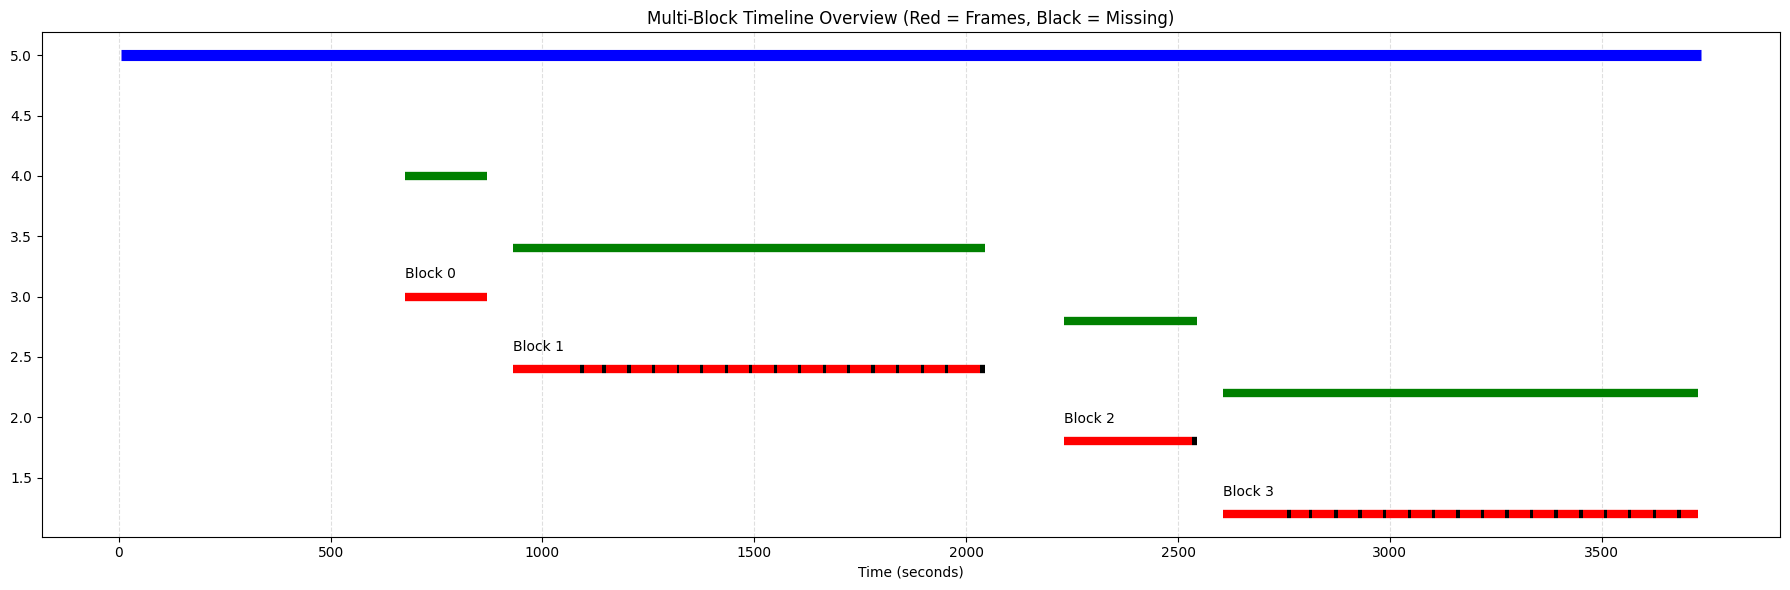


===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====



In [11]:
# ============================================================
# ========== CELL C — MULTI-BLOCK TIMELINE VISUALIZATION =====
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("\n===== Multi-Block Timeline Visualization =====")

# ------------------------------------------------------------
# 1. Load NI-DAQ full-session TTL data (for context)
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

bit_mask = 1 << TTL_PIN
ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times_full = timestamps_ni[rising_edges]

print(f"Full-session TTL pulses: {len(ttl_times_full)}")

ni_start = timestamps_ni[0]
ni_end   = timestamps_ni[-1]

# ------------------------------------------------------------
# 2. Collect block timelines
# ------------------------------------------------------------
block_segments = []   # list of dicts with block info

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = block["ttl_times"]
    aligned_frames = block["aligned_frames"]

    if aligned_frames is None:
        raise RuntimeError(f"Block {block_index} has no aligned_frames. Run CELL B first.")

    block_start = ttl_times_block[0]
    block_end   = ttl_times_block[-1]

    print(f"\n--- Block {block_index} ---")
    print(f"TTL pulses: {len(ttl_times_block)}")
    print(f"Start: {block_start:.3f} s")
    print(f"End:   {block_end:.3f} s")

    block_segments.append({
        "index": block_index,
        "ttl_times": ttl_times_block,
        "aligned_frames": aligned_frames,
        "start": block_start,
        "end": block_end,
    })

print("\nCollected all block timelines.")

# ------------------------------------------------------------
# 3. Plot everything on one figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 6))

# Row positions
y_ni = 5
y_ttl_base = 4
y_frames_base = 3

# --- NI-DAQ full recording ---
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=8, label="NI-DAQ Recording")

# --- Plot each block ---
for seg in block_segments:

    b = seg["index"]
    ttl_times_block = seg["ttl_times"]
    aligned_frames = seg["aligned_frames"]

    y_ttl = y_ttl_base - b * 0.6
    y_frames = y_frames_base - b * 0.6

    # TTL block window
    ax.hlines(y_ttl, seg["start"], seg["end"], color='green', linewidth=6)

    # Frame timeline
    TTL_COUNT = len(ttl_times_block)
    for i, f in enumerate(aligned_frames):
        t0 = ttl_times_block[i]
        if i < TTL_COUNT - 1:
            t1 = ttl_times_block[i+1]
        else:
            t1 = t0 + (ttl_times_block[-1] - ttl_times_block[-2])

        color = 'red' if f is not None else 'black'
        ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

    ax.text(seg["start"], y_frames + 0.15, f"Block {b}", fontsize=10)

# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------
ax.set_xlabel("Time (seconds)")
ax.set_title("Multi-Block Timeline Overview (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====\n")

In [12]:
# ============================================================
# ========== CELL D — DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====
# ============================================================

import os
import numpy as np
import pandas as pd

print("\n===== DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====")

for block_index, block in enumerate(session["blocks"]):

    print(f"\n==============================")
    print(f"Processing block {block_index}")
    print("==============================")

    ttl_times_block = block["ttl_times"]
    aligned_frames = block["aligned_frames"]
    DLC_OUTPUT_PATH = block["dlc_path"]
    CAM_FOLDER = block["cam_folder"]

    if aligned_frames is None:
        raise RuntimeError(f"Block {block_index} has no aligned_frames. Run CELL B first.")

    TTL_COUNT = len(aligned_frames)
    print(f"TTL entries: {TTL_COUNT}")

    # ------------------------------------------------------------
    # 1. Load DLC output
    # ------------------------------------------------------------
    if DLC_OUTPUT_PATH.endswith(".csv"):
        df_dlc = pd.read_csv(DLC_OUTPUT_PATH)
    elif DLC_OUTPUT_PATH.endswith(".h5") or DLC_OUTPUT_PATH.endswith(".hdf5"):
        df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)
    else:
        raise ValueError("DLC output must be .csv or .h5")

    DLC_FRAME_COUNT = len(df_dlc)
    print(f"DLC rows: {DLC_FRAME_COUNT}")

    # ------------------------------------------------------------
    # 2. DLC row mapping
    # ------------------------------------------------------------
    dlc_by_row = {i: df_dlc.iloc[i] for i in range(DLC_FRAME_COUNT)}

    present_raw_indices = [
        int(f.split("_")[1])
        for f in aligned_frames
        if f is not None
    ]

    raw_to_dlc_row = {
        raw_idx: i
        for i, raw_idx in enumerate(present_raw_indices)
        if i < DLC_FRAME_COUNT
    }

    # ------------------------------------------------------------
    # 3. Build TTL-aligned DLC timeline
    # ------------------------------------------------------------
    dlc_aligned = []

    for f in aligned_frames:
        if f is None:
            dlc_aligned.append(None)
        else:
            raw_idx = int(f.split("_")[1])
            dlc_row = raw_to_dlc_row.get(raw_idx, None)
            dlc_aligned.append(dlc_by_row[dlc_row] if dlc_row is not None else None)

    dlc_aligned = np.array(dlc_aligned, dtype=object)

    print(f"Aligned DLC length: {len(dlc_aligned)}")
    print(f"Missing DLC entries: {sum(x is None for x in dlc_aligned)}")

    # ------------------------------------------------------------
    # 4. Save output
    # ------------------------------------------------------------
    out_path = os.path.join(CAM_FOLDER, f"dlc_aligned_block{block_index}.npy")
    np.save(out_path, dlc_aligned)

    print(f"Saved dlc_aligned_block{block_index}.npy → {out_path}")

    # ------------------------------------------------------------
    # 5. Store in session object
    # ------------------------------------------------------------
    block["dlc_aligned"] = dlc_aligned

print("\n===== ALL BLOCKS DLC ALIGNMENT COMPLETE =====\n")


===== DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====

Processing block 0
TTL entries: 11632
DLC rows: 59140
Aligned DLC length: 11632
Missing DLC entries: 2
Saved dlc_aligned_block0.npy → D:\Kevin\05032026\05032026-6\cam2\dlc_aligned_block0.npy

Processing block 1
TTL entries: 66686
DLC rows: 59140
Aligned DLC length: 66686
Missing DLC entries: 8039
Saved dlc_aligned_block1.npy → D:\Kevin\05032026\05032026-7\cam2\dlc_aligned_block1.npy

Processing block 2
TTL entries: 18733
DLC rows: 59140
Aligned DLC length: 18733
Missing DLC entries: 601
Saved dlc_aligned_block2.npy → D:\Kevin\05032026\05032026-8\cam2\dlc_aligned_block2.npy

Processing block 3
TTL entries: 67168
DLC rows: 59140
Aligned DLC length: 67168
Missing DLC entries: 8028
Saved dlc_aligned_block3.npy → D:\Kevin\05032026\05032026-9\cam2\dlc_aligned_block3.npy

===== ALL BLOCKS DLC ALIGNMENT COMPLETE =====




===== Full-Session DLC Trajectory on NIDAQ Timeline =====


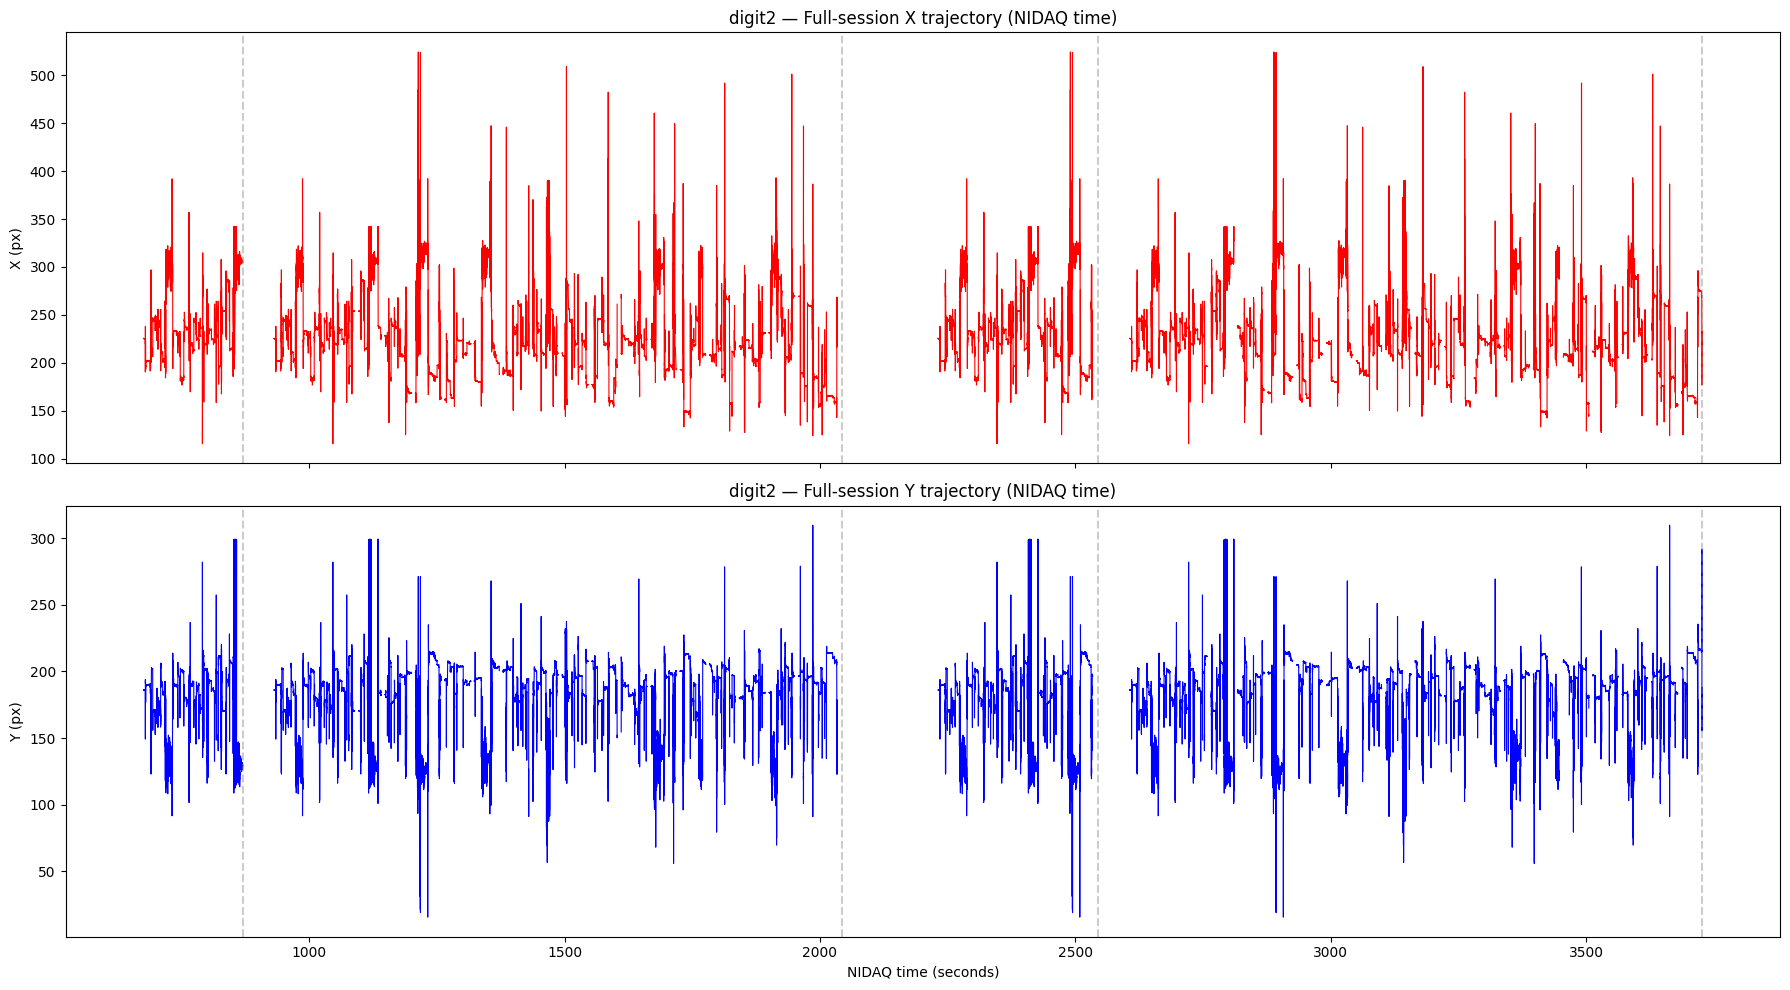


===== FULL-SESSION DLC TRAJECTORY PLOTTING COMPLETE =====



In [13]:
# ============================================================
# ========== CELL E — FULL-SESSION DLC TRAJECTORY PLOT =======
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n===== Full-Session DLC Trajectory on NIDAQ Timeline =====")

bodypart = "digit2"

# ------------------------------------------------------------
# 1. Load DLC column structure from block 0
# ------------------------------------------------------------
df0 = pd.read_hdf(session["blocks"][0]["dlc_path"])
cols = [c for c in df0.columns if c[1] == bodypart]
x_col = [c for c in cols if c[2] == "x"][0]
y_col = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 2. Build full-session arrays
# ------------------------------------------------------------
full_times = []
full_x = []
full_y = []
block_boundaries = []

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = block["ttl_times"]
    dlc_aligned = block["dlc_aligned"]

    if dlc_aligned is None:
        raise RuntimeError(f"Block {block_index} missing dlc_aligned. Run CELL D first.")

    x_vals = []
    y_vals = []

    for row in dlc_aligned:
        if row is None:
            x_vals.append(np.nan)
            y_vals.append(np.nan)
        else:
            x_vals.append(row[x_col])
            y_vals.append(row[y_col])

    full_times.extend(ttl_times_block)
    full_x.extend(x_vals)
    full_y.extend(y_vals)

    block_boundaries.append(ttl_times_block[-1])

full_times = np.array(full_times)
full_x = np.array(full_x)
full_y = np.array(full_y)

# ------------------------------------------------------------
# 3. Plot full-session trajectories
# ------------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ax[0].plot(full_times, full_x, color='red', linewidth=0.8)
ax[0].set_ylabel("X (px)")
ax[0].set_title(f"{bodypart} — Full-session X trajectory (NIDAQ time)")

ax[1].plot(full_times, full_y, color='blue', linewidth=0.8)
ax[1].set_ylabel("Y (px)")
ax[1].set_xlabel("NIDAQ time (seconds)")
ax[1].set_title(f"{bodypart} — Full-session Y trajectory (NIDAQ time)")

# Mark block boundaries
for t in block_boundaries:
    ax[0].axvline(t, color='gray', linestyle='--', alpha=0.4)
    ax[1].axvline(t, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n===== FULL-SESSION DLC TRAJECTORY PLOTTING COMPLETE =====\n")

In [21]:
# ============================================================
# ========== CELL QC — PORTABLE FIRING RATE MATRIX ===========
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import json
from pathlib import Path
import pandas as pd

print("\n===== FIRING RATE QC (PORTABLE + PHY GOOD UNITS) =====")

qc_dir = analysis_folder / "qc"
qc_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 0. Check for cached QC files
# ------------------------------------------------------------
rate_path = qc_dir / "rate_matrix.npy"
centers_path = qc_dir / "centers.npy"
good_units_path = qc_dir / "good_units.npy"
unit_ids_path = qc_dir / "unit_ids.npy"
duration_path = qc_dir / "recording_duration.json"

if (rate_path.exists() and centers_path.exists() and 
    good_units_path.exists() and unit_ids_path.exists() and duration_path.exists()):
    
    print("Found existing QC files — loading cached results.")

    rate_matrix = np.load(rate_path)
    centers = np.load(centers_path)
    good_units = np.load(good_units_path)
    unit_ids = np.load(unit_ids_path)

    with open(duration_path, "r") as f:
        recording_duration = json.load(f)["recording_duration"]

    print("Loaded cached QC data successfully.")

else:
    print("No cached QC files found — computing firing rates from scratch.")

    # ------------------------------------------------------------
    # 1. Load sorting from Kilosort folder
    # ------------------------------------------------------------
    print(f"Loading Kilosort data from:\n{kilosort_path}")

    sorting = si.read_kilosort(kilosort_path)
    unit_ids = sorting.get_unit_ids()

    print(f"Loaded {len(unit_ids)} total units")

    # ------------------------------------------------------------
    # 2. Load Phy cluster groups to get GOOD units
    # ------------------------------------------------------------
    cluster_info_path = kilosort_path / "cluster_info.tsv"
    cluster_group_path = kilosort_path / "cluster_group.tsv"

    if cluster_info_path.exists():
        df = pd.read_csv(cluster_info_path, sep="\t")
        good_units = df[df["group"] == "good"]["cluster_id"].values
    else:
        df = pd.read_csv(cluster_group_path, sep="\t", header=None, names=["cluster_id", "group"])
        good_units = df[df["group"] == "good"]["cluster_id"].values

    print(f"Found {len(good_units)} GOOD units from Phy")

    # ------------------------------------------------------------
    # 3. Extract spike trains for GOOD units only
    # ------------------------------------------------------------
    spike_trains = {u: sorting.get_unit_spike_train(u) for u in good_units}

    all_spikes = np.concatenate([spike_trains[u] for u in good_units])
    recording_duration = all_spikes.max() / sorting.get_sampling_frequency()

    print(f"Recording duration: {recording_duration:.2f} sec")

    # ------------------------------------------------------------
    # 4. Bin + smooth firing rates
    # ------------------------------------------------------------
    BIN_SIZE = 0.020   ############################################################################################################################################################### (20 ms)
    SMOOTH_SIGMA = 3   ############################################################################################################################################################### (Gaussian smoothing)

    bin_edges = np.arange(0, recording_duration + BIN_SIZE, BIN_SIZE)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    rate_matrix = np.zeros((len(good_units), len(centers)))

    for i, u in enumerate(good_units):
        spikes_sec = spike_trains[u] / sorting.get_sampling_frequency()
        counts, _ = np.histogram(spikes_sec, bins=bin_edges)
        rate = counts / BIN_SIZE
        rate_matrix[i] = si.gaussian_filter(rate, sigma=SMOOTH_SIGMA)

    print("Computed firing rate matrix")

    # ------------------------------------------------------------
    # 5. SAVE PORTABLE OUTPUTS
    # ------------------------------------------------------------
    np.save(rate_path, rate_matrix)
    np.save(centers_path, centers)
    np.save(good_units_path, good_units)
    np.save(unit_ids_path, unit_ids)

    with open(duration_path, "w") as f:
        json.dump({"recording_duration": float(recording_duration)}, f)

    print("\nSaved QC outputs:")
    print(f"  {rate_path.name}")
    print(f"  {centers_path.name}")
    print(f"  {good_units_path.name}")
    print(f"  {unit_ids_path.name}")
    print(f"  {duration_path.name}")

# ------------------------------------------------------------
# 6. Plot heatmap (KEEP FOREVER)
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')
plt.colorbar(label="Firing rate (Hz)")
plt.title("Firing Rate Heatmap (GOOD Units)")
plt.xlabel("Time (s)")
plt.ylabel("Good unit index")
plt.show()

print("\n===== FIRING RATE QC COMPLETE =====\n")


===== FIRING RATE QC (PORTABLE + PHY GOOD UNITS) =====


NameError: name 'analysis_folder' is not defined


===== Building Full-Session RAW DLC + Physiology Figure =====
Detected 87 behavioral TTLs on pin 7


NameError: name 'rate_matrix' is not defined

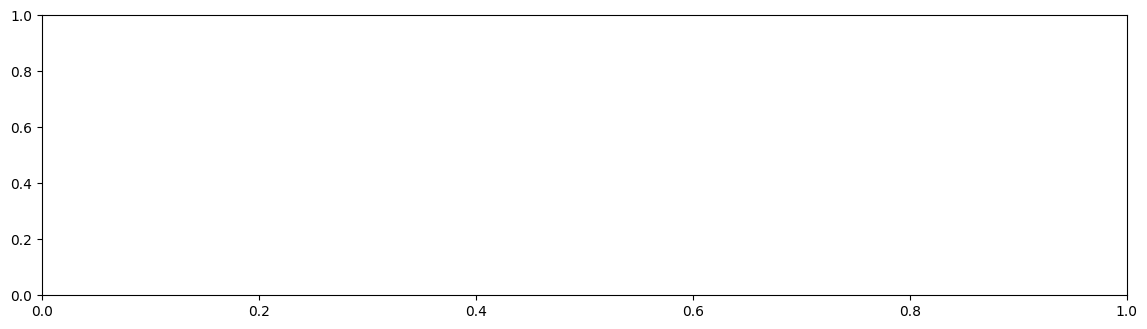

In [19]:
# ============================================================
# ========== FINAL CELL — RAW DLC + FIRING HEATMAP ============
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n===== Building Full-Session RAW DLC + Physiology Figure =====")

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
bodypart = "digit1"
BEHAVIOR_HEIGHT = 2.0   # inches
HEATMAP_HEIGHT = 6.0    # inches

BEHAVIOR_PIN = 7        # TTL pin for behavioral events
DRAW_LABELS = True     # set True to label each TTL
SHADE_AFTER_TTL = True # set True to shade a window after each TTL
SHADE_WINDOW = 0.15     # seconds (only used if SHADE_AFTER_TTL=True)

# ------------------------------------------------------------
# 0. Extract behavioral TTL rising edges
# ------------------------------------------------------------
def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0

    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False

    rising = (~bit_prev) & bit_on
    return timestamps[rising]

behavior_ttls = extract_rising_edges(full_words_ni, timestamps_ni, BEHAVIOR_PIN)
print(f"Detected {len(behavior_ttls)} behavioral TTLs on pin {BEHAVIOR_PIN}")

# ------------------------------------------------------------
# 1. Load DLC column structure from block 0
# ------------------------------------------------------------
df0 = pd.read_hdf(session["blocks"][0]["dlc_path"])
cols = [c for c in df0.columns if c[1] == bodypart]
x_col = [c for c in cols if c[2] == "x"][0]
y_col = [c for c in cols if c[2] == "y"][0]

# ------------------------------------------------------------
# 2. Build full-session raw DLC trajectories
# ------------------------------------------------------------
full_times = []
full_x = []
full_y = []

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = block["ttl_times"]
    dlc_aligned = block["dlc_aligned"]

    if dlc_aligned is None:
        raise RuntimeError(f"Block {block_index} missing dlc_aligned. Run CELL D first.")

    x_vals = []
    y_vals = []

    for row in dlc_aligned:
        if row is None:
            x_vals.append(np.nan)
            y_vals.append(np.nan)
        else:
            x_vals.append(row[x_col])
            y_vals.append(row[y_col])

    full_times.extend(ttl_times_block)
    full_x.extend(x_vals)
    full_y.extend(y_vals)

full_times = np.array(full_times)
full_x = np.array(full_x, dtype=float)
full_y = np.array(full_y, dtype=float)

# ------------------------------------------------------------
# 3. Build combined figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, HEATMAP_HEIGHT + BEHAVIOR_HEIGHT))

# ---- Top: firing rate heatmap ----
ax1 = fig.add_subplot(2, 1, 1)

ax1.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

ax1.set_title("Firing rate over session (GOOD units, smoothed)")
ax1.set_ylabel("Unit")
ax1.set_xticks([])  # hide x-axis here

# ---- Bottom: raw DLC trace ----
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

ax2.plot(full_times, full_x, color='red', linewidth=0.5, label="X (px)")
ax2.plot(full_times, full_y, color='blue', linewidth=0.5, label="Y (px)")

# ------------------------------------------------------------
# 4. Add behavioral TTL markers
# ------------------------------------------------------------
for i, t in enumerate(behavior_ttls):

    # vertical dashed line
    ax2.axvline(t, color='green', linestyle='--', linewidth=0.8, alpha=0.7)

    # optional label
    if DRAW_LABELS:
        ax2.text(t, np.nanmax(full_y) + 5, f"{i}",
                 rotation=90, fontsize=6, color='green',
                 verticalalignment='bottom')

    # optional shaded window after TTL
    if SHADE_AFTER_TTL:
        ax2.axvspan(t, t + SHADE_WINDOW, color='green', alpha=0.15)

# ------------------------------------------------------------
# 5. Final formatting
# ------------------------------------------------------------
ax2.set_ylabel("Pixels")
ax2.set_xlabel("Time (s)")
ax2.set_title(f"Raw DLC Trajectory — {bodypart} (Full Session)")
ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("\n===== RAW DLC + PHYSIOLOGY FIGURE COMPLETE =====\n")


In [16]:
# ============================================================
# ========== PERI-TTL ZOOM: BEHAVIOR + PHYSIOLOGY ============
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n===== Peri-TTL Behavior + Physiology Zoom =====")

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
PIN = 7                 # TTL pin to zoom around
WIN_PRE = 2.0           # seconds before TTL
WIN_POST = 20.0         # seconds after TTL
MAX_TTLS = 10           # limit how many TTLs to plot (set None for all)

bodypart = "digit1"

# ------------------------------------------------------------
# 1. Extract rising edges on this pin
# ------------------------------------------------------------
def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

ttls = extract_rising_edges(full_words_ni, timestamps_ni, PIN)
print(f"Found {len(ttls)} TTLs on pin {PIN}")

# ------------------------------------------------------------
# 2. Build full-session DLC arrays (already done earlier)
# ------------------------------------------------------------
# We assume full_times, full_x, full_y already exist from your previous cell.
# If not, you can re-run that cell first.

# ------------------------------------------------------------
# 3. Loop through TTLs and plot peri-event windows
# ------------------------------------------------------------
if MAX_TTLS is not None:
    ttls = ttls[:MAX_TTLS]

for idx, t_event in enumerate(ttls):

    t0 = t_event - WIN_PRE
    t1 = t_event + WIN_POST

    # mask for DLC
    mask = (full_times >= t0) & (full_times <= t1)

    # mask for firing rate heatmap
    mask_fr = (centers >= t0) & (centers <= t1)

    if not np.any(mask):
        continue

    fig = plt.figure(figsize=(14, 6))

    # --------------------------------------------------------
    # Top: firing rate heatmap (cropped)
    # --------------------------------------------------------
    ax1 = fig.add_subplot(2, 1, 1)

    ax1.imshow(rate_matrix[:, mask_fr],
               aspect='auto',
               extent=[t0, t1, 0, len(good_units)],
               origin='lower')

    ax1.axvline(t_event, color='green', linestyle='--', linewidth=1)
    ax1.set_title(f"Firing Rate (TTL {idx} at t={t_event:.2f}s)")
    ax1.set_ylabel("Unit")
    ax1.set_xticks([])

    # --------------------------------------------------------
    # Bottom: raw DLC trace (cropped)
    # --------------------------------------------------------
    ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

    ax2.plot(full_times[mask], full_x[mask], color='red', linewidth=0.7, label="X")
    ax2.plot(full_times[mask], full_y[mask], color='blue', linewidth=0.7, label="Y")

    ax2.axvline(t_event, color='green', linestyle='--', linewidth=1)

    ax2.set_ylabel("Pixels")
    ax2.set_xlabel("Time (s)")
    ax2.set_title(f"Raw DLC Trajectory (TTL {idx})")
    ax2.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

print("\n===== Peri-TTL Zoom Complete =====\n")


===== Peri-TTL Behavior + Physiology Zoom =====
Found 87 TTLs on pin 7


NameError: name 'centers' is not defined


===== Block-Aware Continuous Movement Magnitude =====
Loaded dlc_aligned_block3.npy with 67168 entries.
Saved movement magnitude → D:\Kevin\05032026\05032026-9\cam2\movement_magnitude_block3.npy


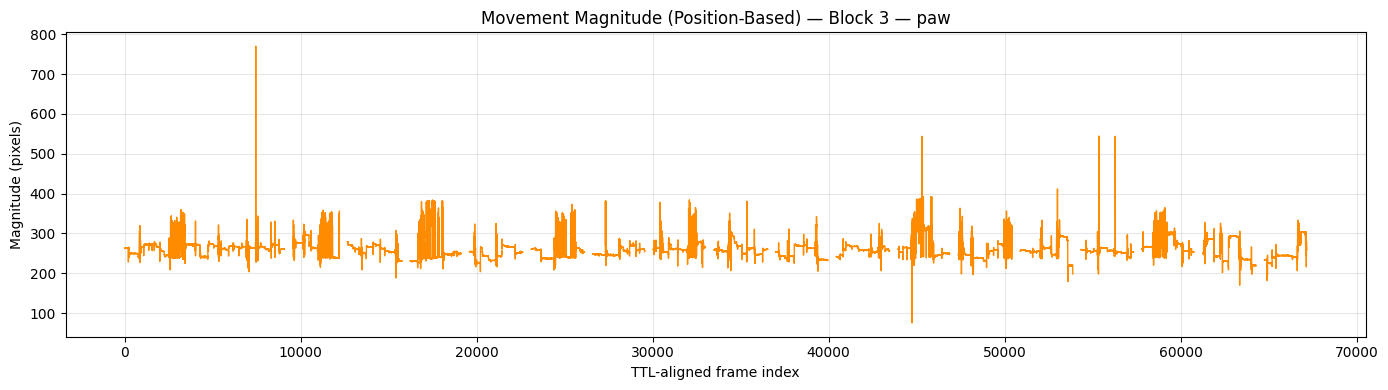


===== MOVEMENT MAGNITUDE COMPLETE =====



In [33]:
# ============================================================
# ========== CELL E — CONTINUOUS MOVEMENT MAGNITUDE ==========
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n===== Block-Aware Continuous Movement Magnitude =====")

# ------------------------------------------------------------
# REQUIRED INPUTS
# ------------------------------------------------------------
# CAM_FOLDER
# block_index
# DLC_OUTPUT_PATH
# bodypart_name (e.g., "paw", "digit2", etc.)

bodypart_name = "paw"   # <--- set manually ##########################################################################################################################################################

# ------------------------------------------------------------
# 1. Load block-specific DLC-aligned data
# ------------------------------------------------------------
dlc_path = os.path.join(CAM_FOLDER, f"dlc_aligned_block{block_index}.npy")
dlc_aligned = np.load(dlc_path, allow_pickle=True)

print(f"Loaded dlc_aligned_block{block_index}.npy with {len(dlc_aligned)} entries.")

# ------------------------------------------------------------
# 2. Load DLC dataframe to inspect column structure
# ------------------------------------------------------------
df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

# DLC columns are MultiIndex: (scorer, bodypart, coord)
cols = [c for c in df_dlc.columns if c[1] == bodypart_name]

x_col   = [c for c in cols if c[2] == "x"][0]
y_col   = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 3. Extract TTL-aligned x,y coordinates
# ------------------------------------------------------------
x = []
y = []

for row in dlc_aligned:
    if row is None:
        x.append(np.nan)
        y.append(np.nan)
    else:
        x.append(row[x_col])
        y.append(row[y_col])

x = np.array(x, dtype=float)
y = np.array(y, dtype=float)

# ------------------------------------------------------------
# 4. Compute continuous magnitude (position-based)
# ------------------------------------------------------------
magnitude = np.sqrt(x**2 + y**2)

# Optional: center around mean resting position
# magnitude = np.sqrt((x - np.nanmean(x))**2 + (y - np.nanmean(y))**2)

# ------------------------------------------------------------
# 5. Save magnitude
# ------------------------------------------------------------
out_path = os.path.join(CAM_FOLDER, f"movement_magnitude_block{block_index}.npy")
np.save(out_path, magnitude)

print(f"Saved movement magnitude → {out_path}")

# ------------------------------------------------------------
# 6. Plot magnitude
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(magnitude, color='darkorange', linewidth=1)
plt.title(f"Movement Magnitude (Position-Based) — Block {block_index} — {bodypart_name}")
plt.xlabel("TTL-aligned frame index")
plt.ylabel("Magnitude (pixels)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n===== MOVEMENT MAGNITUDE COMPLETE =====\n")

In [34]:
# ============================================================
# ========== CELL F — SANITY CHECK MODULE ====================
# ============================================================

import os
import numpy as np

print("\n===== Sanity Check Module =====")

aligned_frames = np.load(os.path.join(CAM_FOLDER, "aligned_frames.npy"), allow_pickle=True)
dlc_aligned    = np.load(os.path.join(CAM_FOLDER, "dlc_aligned.npy"), allow_pickle=True)

TTL_COUNT = len(aligned_frames)

print(f"TTL count: {TTL_COUNT}")
print(f"DLC-aligned length: {len(dlc_aligned)}")

# ------------------------------------------------------------
# 1. Check that every present frame has a DLC entry
# ------------------------------------------------------------
present_frames = sum(f is not None for f in aligned_frames)
present_dlc    = sum(x is not None for x in dlc_aligned)

print(f"Present frames: {present_frames}")
print(f"Present DLC entries: {present_dlc}")

if present_frames != present_dlc:
    print("⚠️ Mismatch detected: DLC entries do not match present frames.")
else:
    print("✅ DLC entries match present frames exactly.")

# ------------------------------------------------------------
# 2. Check for any DLC values outside expected range
# ------------------------------------------------------------
y_vals = np.array([
    row[y_col] if row is not None else np.nan
    for row in dlc_aligned
])

print(f"Max Y in DLC-aligned: {np.nanmax(y_vals)}")
print(f"Min Y in DLC-aligned: {np.nanmin(y_vals)}")

print("\n===== MODULE COMPLETE =====\n")


===== Sanity Check Module =====


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Kevin\\05032026\\05032026-9\\cam2\\aligned_frames.npy'


===== Block-Aware Peak Detection (with outlier filtering) =====
Detected 63 valid peaks.

===== PEAK RESULTS =====
TTL    211 | Frame 211 | X = 237.66
TTL   1183 | Frame 1183 | X = 244.52
TTL   1383 | Frame 1383 | X = 246.13
TTL   1765 | Frame 1765 | X = 243.35
TTL   1976 | Frame 1976 | X = 236.99
TTL   5488 | Frame 5488 | X = 248.87
TTL   5903 | Frame 5903 | X = 237.03
TTL   6187 | Frame 6187 | X = 241.53
TTL   6649 | Frame 6649 | X = 247.18
TTL   7000 | Frame 7000 | X = 239.02
TTL   7564 | Frame 7564 | X = 263.26
TTL   8331 | Frame 8331 | X = 259.81
TTL   9691 | Frame 9198 | X = 254.35
TTL   9936 | Frame 9443 | X = 244.58
TTL  10190 | Frame 9697 | X = 255.71
TTL  10574 | Frame 10081 | X = 263.50
TTL  11122 | Frame 10629 | X = 249.53
TTL  12647 | Frame 11709 | X = 239.91
TTL  12852 | Frame 11914 | X = 236.74
TTL  13728 | Frame 12790 | X = 243.20
TTL  14772 | Frame 13834 | X = 235.18
TTL  15429 | Frame 14491 | X = 247.32
TTL  16858 | Frame 15458 | X = 239.54
TTL  17132 | Frame 15732 |

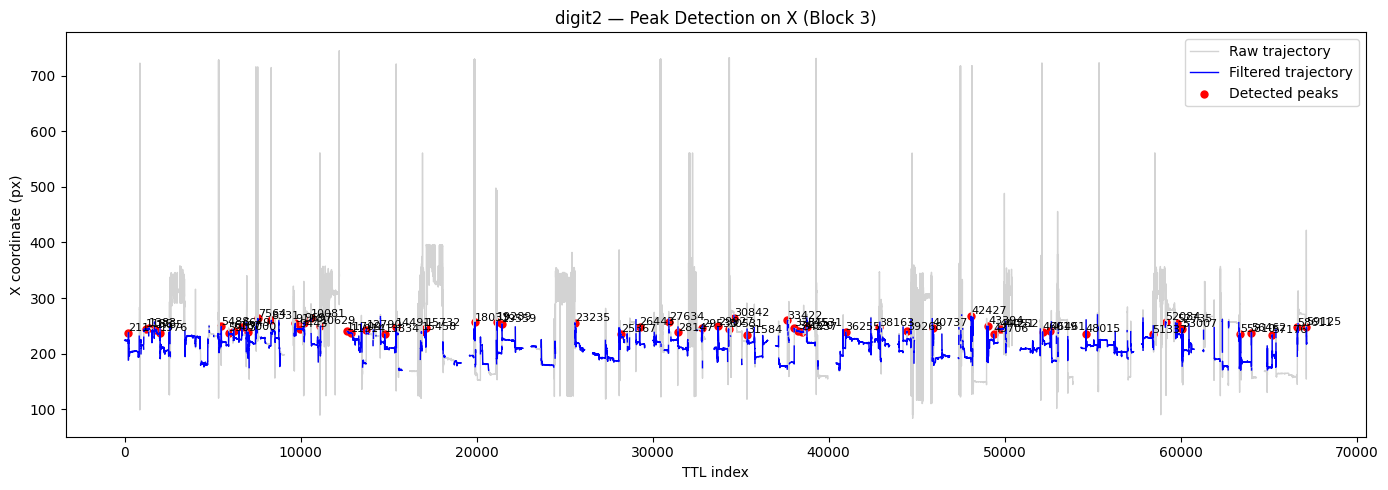


===== PEAK DETECTION COMPLETE =====



In [45]:
# ============================================================
# ========== BLOCK-AWARE PEAK DETECTION (FULL LOOP) ==========
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

print("\n===== Running Block-Aware Peak Detection =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------
bodypart_name = "digit2"
coord_to_use  = "x"          # "x" or "y"

# realistic coordinate bounds
x_low, x_high = 170, 270
y_low, y_high = 100, 350

lik_threshold = 0.6
threshold = 233
min_peak_distance = 200

# ------------------------------------------------------------
# STORAGE FOR ALL BLOCKS
# ------------------------------------------------------------
all_block_results = {}   # block_index → list of (ttl_idx, raw_idx, peak_val)
all_block_peaks   = {}   # block_index → np.array of peak TTL indices

# ------------------------------------------------------------
# MAIN LOOP OVER BLOCKS
# ------------------------------------------------------------
for block_index in CAM_FOLDERS.keys():

    print(f"\n===== Processing Block {block_index} =====")

    CAM_FOLDER = CAM_FOLDERS[block_index]
    DLC_OUTPUT_PATH = DLC_OUTPUTS[block_index]

    # --------------------------------------------------------
    # 1. Load aligned DLC data
    # --------------------------------------------------------
    dlc_path = os.path.join(CAM_FOLDER, f"dlc_aligned_block{block_index}.npy")
    aligned_frames_path = os.path.join(CAM_FOLDER, f"aligned_frames_block{block_index}.npy")

    dlc_aligned = np.load(dlc_path, allow_pickle=True)
    aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

    TTL_COUNT = len(aligned_frames)
    assert len(dlc_aligned) == TTL_COUNT

    # --------------------------------------------------------
    # 2. Load DLC dataframe to get column structure
    # --------------------------------------------------------
    df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

    cols = [c for c in df_dlc.columns if c[1] == bodypart_name]
    x_col   = [c for c in cols if c[2] == "x"][0]
    y_col   = [c for c in cols if c[2] == "y"][0]
    lik_col = [c for c in cols if c[2] == "likelihood"][0]

    # --------------------------------------------------------
    # 3. Build aligned trajectories
    # --------------------------------------------------------
    traj = []
    lik = []

    for row in dlc_aligned:
        if row is None:
            traj.append(np.nan)
            lik.append(np.nan)
        else:
            traj.append(row[x_col] if coord_to_use == "x" else row[y_col])
            lik.append(row[lik_col])

    traj = np.array(traj, dtype=float)
    lik  = np.array(lik, dtype=float)

    # --------------------------------------------------------
    # 4. Validity mask
    # --------------------------------------------------------
    if coord_to_use == "x":
        valid_range = (traj > x_low) & (traj < x_high)
    else:
        valid_range = (traj > y_low) & (traj < y_high)

    valid_mask = valid_range & (lik > lik_threshold)

    traj_filtered = traj.copy()
    traj_filtered[~valid_mask] = np.nan

    # --------------------------------------------------------
    # 5. Peak detection
    # --------------------------------------------------------
    peaks, props = find_peaks(
        traj_filtered,
        height=threshold,
        distance=min_peak_distance
    )

    print(f"Detected {len(peaks)} peaks in block {block_index}.")

    # --------------------------------------------------------
    # 6. Store results
    # --------------------------------------------------------
    block_results = []
    for ttl_idx in peaks:
        fname = aligned_frames[ttl_idx]
        raw_idx = int(fname.split("_")[1]) if fname is not None else None
        peak_val = traj_filtered[ttl_idx]
        block_results.append((ttl_idx, raw_idx, peak_val))

    all_block_results[block_index] = block_results
    all_block_peaks[block_index] = peaks

    # --------------------------------------------------------
    # 7. Plot per block
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(traj, color='lightgray', linewidth=1, label="Raw trajectory")
    ax.plot(traj_filtered, color='blue', linewidth=1, label="Filtered trajectory")
    ax.scatter(peaks, traj_filtered[peaks], color='red', s=25, label="Detected peaks")

    for ttl_idx, raw_idx, peak_val in block_results:
        if raw_idx is not None:
            ax.text(ttl_idx, peak_val + 3, str(raw_idx), fontsize=8, color='black')

    ax.set_title(f"{bodypart_name} — Peak Detection on {coord_to_use.upper()} (Block {block_index})")
    ax.set_xlabel("TTL index")
    ax.set_ylabel(f"{coord_to_use.upper()} coordinate (px)")
    ax.legend()

    plt.tight_layout()
    plt.show()

print("\n===== ALL BLOCKS COMPLETE =====\n")


In [18]:
# =========================
# CELL 1: LOAD DATA + GROUPS
# =========================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import pandas as pd
import os

# ---- PATH ----
phy_path = r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

# ---- LOAD ----
sorting = se.read_phy(phy_path)

cg_path = os.path.join(phy_path, "cluster_group.tsv")
df = pd.read_csv(cg_path, sep="\t")

unit_ids_all = sorting.get_unit_ids()
sf = sorting.get_sampling_frequency()

# ---- GROUPS ----
good_cluster_ids = set(df[df["group"] == "good"]["cluster_id"].values)
noise_cluster_ids = set(df[df["group"] == "noise"]["cluster_id"].values)

good_units = [u for u in unit_ids_all if u in good_cluster_ids]
noise_units = [u for u in unit_ids_all if u in noise_cluster_ids]

sorting_good = sorting.select_units(good_units)
sorting_noise = sorting.select_units(noise_units)

print(f"✅ Good units: {len(good_units)}")
print(f"⚠️ Noise units: {len(noise_units)}")

# =========================
# LOAD NI TTL + SELECT PIN
# =========================

import numpy as np
import os

# ---- SET PATH ----
ni_folder = r"G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL"

# ---- SELECT TTL PIN ----
TTL_PIN = 7   # 👈 CHANGE THIS (0–15 typically)

print("Using NI folder:")
print(ni_folder)
print(f"Using TTL pin: {TTL_PIN}")

# ---- LOAD FILES ----
timestamps_path = os.path.join(ni_folder, "timestamps.npy")
states_path     = os.path.join(ni_folder, "states.npy")
full_words_path = os.path.join(ni_folder, "full_words.npy")

if not os.path.exists(full_words_path):
    print("❌ TTL files not found")

else:
    timestamps_ni = np.load(timestamps_path)
    states_ni     = np.load(states_path)
    full_words_ni = np.load(full_words_path)

    print("✅ TTL data loaded")
    print("Samples:", len(full_words_ni))
    print("Duration (s):", timestamps_ni[-1] - timestamps_ni[0])

    # =========================
    # EXTRACT SPECIFIC TTL CHANNEL
    # =========================
    bit_mask = 1 << TTL_PIN

    ttl_signal = (full_words_ni & bit_mask) > 0  # boolean signal

    # ---- FIND RISING EDGES ----
    ttl_diff = np.diff(ttl_signal.astype(int))

    rising_edges = np.where(ttl_diff == 1)[0] + 1

    ttl_times_all = timestamps_ni[rising_edges] # ✅ keep original

    ttl_times = ttl_times_all.copy()  # working variable

    print(f"⏱️ Extracted {len(ttl_times_all)} TTL events from pin {TTL_PIN}")

    print(f"⏱️ Extracted {len(ttl_times)} TTL events from pin {TTL_PIN}")

# =========================
# TTL REFRACTORY FILTER
# =========================

min_interval = 5.0  # seconds (your choice)

filtered_ttl_times = []
last_kept_time = -np.inf

for t in ttl_times:
    if t - last_kept_time >= min_interval:
        filtered_ttl_times.append(t)
        last_kept_time = t

filtered_ttl_times = np.array(filtered_ttl_times)

print(f"\n🧹 TTL filtering applied (min interval = {min_interval}s)")
print(f"Original TTLs: {len(ttl_times)}")
print(f"Filtered TTLs: {len(filtered_ttl_times)}")

# overwrite for downstream analysis
ttl_times = filtered_ttl_times

C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Good units: 192
⚠️ Noise units: 283
Using NI folder:
G:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL
Using TTL pin: 7
✅ TTL data loaded
Samples: 665277
Duration (s): 3729.392
⏱️ Extracted 87 TTL events from pin 7
⏱️ Extracted 87 TTL events from pin 7

🧹 TTL filtering applied (min interval = 5.0s)
Original TTLs: 87
Filtered TTLs: 87


In [17]:
# ============================================================
# FIRING RATE HEATMAP WITH REACH PEAK OVERLAY (BLOCK-AWARE)
# ============================================================

plt.figure(figsize=(14,6))

plt.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.title("Firing rate over session (GOOD units, smoothed)")
plt.colorbar(label="Hz")

# ------------------------------------------------------------
# Overlay reach peaks for the chosen block
# ------------------------------------------------------------

# Convert TTL index → seconds
peak_times_sec = ttl_times_block[peaks]

for t in peak_times_sec:
    plt.axvline(t, color='white', linestyle='--', linewidth=1.0, alpha=0.8)

plt.title(f"Firing rate over session (GOOD units) with reach peaks (block {block_index})")
plt.tight_layout()
plt.show()

NameError: name 'rate_matrix' is not defined

<Figure size 1400x600 with 0 Axes>